In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools
from datetime import datetime
try:
    import winsound
except:
    print("No beep")

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.feature_selection import SelectKBest

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from scipy.stats import loguniform, uniform

from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

In [45]:
# Utility functions
def plot_confusion_matrix(cm, classes,
                          normalize=True,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be changed.
    """

    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()


def eval_pipeline(pipe, name, normalize_cm=True):

    # Hard predictions at the model's default threshold 0.5
    y_pred = pipe.predict(X_te)

    # Per-class precision/recall/F1 plus macro/weighted averages
    print(f"\n=== {name} (best params) ===")
    print(metrics.classification_report(y_te, y_pred, digits=3))

    # Confusion matrix in counts for a concrete error breakdown
    cm = metrics.confusion_matrix(y_te, y_pred)
    print("Confusion matrix (counts):\n", cm)

    # Your helper draws counts or normalized CM depending on normalize_cm
    # Label order should match your y encoding: 0 = 'No diabetes', 1 = 'Diabetes'
    plot_confusion_matrix(cm, ['No diabetes','Diabetes'], normalize_cm)

    # ---- Threshold-independent metrics (use continuous scores) ----
    # Prefer probabilities if available; otherwise fall back to decision_function
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        scores = pipe.predict_proba(X_te)[:, 1]   # P(y=1 | x)
    elif hasattr(pipe.named_steps["model"], "decision_function"):
        scores = pipe.decision_function(X_te)     # larger => more positive
    else:
        # Some estimators expose neither; gracefully skip AUCs
        print("Estimator has neither predict_proba nor decision_function; skipping AUCs.")
        return

    # ROC-AUC: ranking quality vs. FPR; PR-AUC (Average Precision): better for imbalance
    print(f"ROC-AUC: {metrics.roc_auc_score(y_te, scores):.3f}")
    print(f"PR-AUC : {metrics.average_precision_score(y_te, scores):.3f}")



def start_timer():
    global start_time
    start_time = datetime.now()
    print('Start time: ', start_time.strftime('%H:%M:%S'))

def end_timer():
    end_time = datetime.now()
    print('End time: ', end_time.strftime('%H:%M:%S'))
    runtime = end_time - start_time
    print('Runtime: ', runtime,'\n')

def beep_when_done():
    duration = 300  # milliseconds
    freq = 440  # Hz
    try:
        winsound.Beep(freq, duration)
    except:
        print("Beep! (Sound not working)")


In [47]:
data1_filename = "diabetes_binary_health_indicators_BRFSS2015.csv"
df1 = pd.read_csv(data1_filename)

In [49]:
# ---- Target/feature split ----
# Diabetes_binary is already 0/1; cast to int to avoid bool dtype surprises downstream.
y = df1["Diabetes_binary"].astype(int)
X = df1.drop(columns=["Diabetes_binary"])

binary_cols = [c for c in X.columns if set(pd.unique(X[c].dropna())) <= {0, 1}]
numeric_cols = [c for c in X.columns if c not in binary_cols]

# Ensure binary features are ints (not bools/floats), which keeps them 0/1 through the pipeline.
for c in binary_cols:
    X[c] = X[c].astype(int)

# ---- Hold-out split ----
# Stratified split preserves the positive rate (~class imbalance) in both train and test.
# random_state for reproducibility; keep this consistent across experiments.
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



# ---- Preprocessing pipeline ----
# Scale only the continuous features (helps linear/SGD solvers); pass binary 0/1 through unchanged.
# 'remainder="drop"' ensures only specified columns flow downstream, preventing accidental leakage.
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("bin", "passthrough", binary_cols),
    ],
    remainder="drop",
)

# ---- Cross-validation plan ----
# StratifiedKFold maintains class proportions in each fold—crucial for stable metrics on imbalanced data.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# ---- Scoring choice ----
# Default scoring method going forward.
# Options: 'f1', 'average_precision', ‘roc_auc’, 'fbeta', 'recall'
# fbeta = metrics.make_scorer(metrics.fbeta_score, beta=2.0)
scoring = 'f1'

In [ ]:
# Logistic Regression - Stochastic Average Gradient Descent
# LogisticRegression 'sag'

start_timer()

logreg_base = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

# Candidate C values on a log scale (0.001 .. 10). Wider coverage is usually better than linear steps.
log_C = list(np.logspace(-3, 1, 20))

# Use a *list of dicts* to restrict to valid solver/penalty combos:
#   - liblinear supports L1/L2; fast for small/medium tabular data
#   - newton-cholesky supports L2
# Class weight is fixed to "balanced" here to keep recall higher at default threshold.
logreg_param_distributions = {
    "model__solver": ["sag"],
    "model__penalty": ["l2"],
    "model__C": log_C,
    "model__class_weight": ["balanced"]
}

# RandomizedSearchCV samples parameter settings at random; great when the space is large.
# - scoring comes from your earlier choice (e.g., "recall", "f1", or a custom F-beta).
# - refit=True means the best model (by 'scoring') is retrained on the full training set.
# - n_jobs=-1 uses all CPU cores.
logreg_rs = RandomizedSearchCV(
    estimator=logreg_base,
    param_distributions=logreg_param_distributions,
    n_iter=20,                 # increase for a wider search; reduce if runtime is long
    scoring="roc_auc",           # IMPORTANT: ensure this matches objective (e.g., "recall" or "f1")
    cv=cv,
    n_jobs=-1,
    refit=True,
    random_state=42,
    verbose=0
)

# Fit on training fold data only; preprocessing occurs within each CV split properly.
logreg_rs.fit(X_tr, y_tr)


label = (scoring if isinstance(scoring, str)
         else (logreg_rs.refit if isinstance(scoring, dict)
               else getattr(scoring, "_score_func", scoring).__name__))
print(f"LogReg best CV score [{label}]: {logreg_rs.best_score_:.3f}")
print("LogReg best params:", logreg_rs.best_params_)

# Evaluate the *refit* best pipeline on the held-out test set (true generalization check).
eval_pipeline(logreg_rs.best_estimator_, "Logistic Regression (tuned)")

end_timer()
beep_when_done()

Start time:  18:11:34
SGD best CV score [f1]: 0.446
SGD best params: {'model__validation_fraction': 0.1, 'model__tol': 0.0001, 'model__penalty': 'l2', 'model__n_iter_no_change': 15, 'model__max_iter': 6000, 'model__loss': 'log_loss', 'model__l1_ratio': 0.0, 'model__early_stopping': True, 'model__class_weight': 'balanced', 'model__alpha': 0.0001}

=== SGDClassifier (tuned) (best params) ===
              precision    recall  f1-score   support

           0      0.950     0.725     0.822     43667
           1      0.310     0.765     0.441      7069

    accuracy                          0.730     50736
   macro avg      0.630     0.745     0.632     50736
weighted avg      0.861     0.730     0.769     50736

Confusion matrix (counts):
 [[31640 12027]
 [ 1660  5409]]


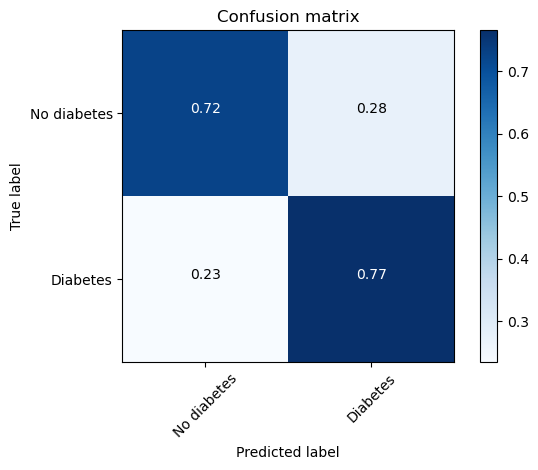

ROC-AUC: 0.819
PR-AUC : 0.390
End time:  18:11:49
Runtime:  0:00:15.106848 



In [27]:
# Logistic Regression - Stochastic Gradient Descent
# SGDClassifier, log_loss

start_timer()

sgd_base = Pipeline([
    ("prep", preprocess),
    ("model", SGDClassifier(random_state=42))
])

# Parameter space:
# - loss: 'log_loss' gives probabilities; 'modified_huber' is robust; 'hinge' is SVM-like (no proba).
# - alpha: L2 regularization strength (λ); smaller -> weaker regularization (can boost recall but risk overfit).
# - penalty: choose regularizer type; 'elasticnet' blends L1/L2 using l1_ratio.
# - early_stopping: monitors a validation split and stops when no improvement.
# - class_weight='balanced': counteracts class imbalance (keeps recall from collapsing at default threshold).
sgd_param_dist = {
    "model__loss": ["log_loss"],
    "model__alpha": [1e-6, 3e-6, 1e-5, 3e-5, 1e-4],
    "model__penalty": ["l2"],
    "model__l1_ratio": [0.0, 0.15, 0.5, 0.9],  # only used when penalty='elasticnet'
    "model__max_iter": [2000, 4000, 6000],
    "model__tol": [1e-4, 1e-3],
    "model__class_weight": ["balanced"],
    "model__early_stopping": [True],          # lets SGD pick iterations automatically
    "model__validation_fraction": [0.1, 0.15, 0.2],
    "model__n_iter_no_change": [5, 10, 15],
}

# RandomizedSearchCV samples combos at random (good for larger spaces).
# - scoring comes from your earlier choice (e.g., 'recall', 'f1', or custom F-beta).
# - refit=True retrains the best setting on the full training data.
sgd_rs = RandomizedSearchCV(
    estimator=sgd_base,
    param_distributions=sgd_param_dist,
    n_iter=20,
    scoring=scoring,     # IMPORTANT: aligns with your objective at default threshold
    cv=cv,
    n_jobs=-1,
    refit=True,
    random_state=42,
    verbose=0
)

# Fit the randomized search on the training split; preprocessing happens within each CV fold.
sgd_rs.fit(X_tr, y_tr)

# Report best CV score with the actual scoring name used
label = (scoring if isinstance(scoring, str)
         else (sgd_rs.refit if isinstance(scoring, dict)
               else getattr(scoring, "_score_func", scoring).__name__))
print(f"SGD best CV score [{label}]: {sgd_rs.best_score_:.3f}")

print("SGD best params:", sgd_rs.best_params_)

# ---------- Evaluate best estimator on the held-out test set ----------
# Uses your eval helper; this keeps threshold at the model's default (0.5 or 0.0 margin).
eval_pipeline(sgd_rs.best_estimator_, "SGDClassifier (tuned)")

end_timer()
beep_when_done()

In [ ]:
# === SVC (undersampled, SelectKBest) with cross-validation ===

start_timer()

svc_base = ImbPipeline([
    ("prep", preprocess),
    ("under", RandomUnderSampler(sampling_strategy="auto", random_state=42)),
    ("select", SelectKBest(k=10)),
    ("model", SVC(kernel="rbf"))
])

svc_param_dist = {
    "model__kernel": ["rbf"],
    "model__C": np.logspace(-2, 2, 30),
    "model__gamma": np.logspace(-4, 1, 30),   # used only for rbf
    "select__k": [8, 10, 12, 14, 16],    # tune how many features to keep
}


svc_rs = RandomizedSearchCV(
    estimator=svc_base,
    param_distributions=svc_param_dist,
    n_iter=40,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=0,
)

svc_rs.fit(X_tr, y_tr)

print("SVC (undersampled, SKB) — best CV score:", svc_rs.best_score_)
print("SVC (undersampled, SKB) — best params:", svc_rs.best_params_)

eval_pipeline(svc_rs.best_estimator_, name="svc_rs")

end_timer(); beep_when_done()

In [ ]:
best = svc_rs.best_estimator_
selector = best.named_steps["select"]
prep = best.named_steps["prep"]

# boolean mask of kept features
mask = selector.get_support()

# Try to get human-readable feature names from your preprocessor
feature_names = None
try:
    # Newer sklearn usually works without args
    feature_names = prep.get_feature_names_out()
except Exception:
    # Older versions may need original column names (if X_tr is a DataFrame)
    try:
        feature_names = prep.get_feature_names_out(
            input_features=getattr(X_tr, "columns", None)
        )
    except Exception:
        pass

# Fallback: generic names if we couldn't resolve real names
if feature_names is None:
    feature_names = np.array([f"feat_{i}" for i in range(mask.shape[0])])

feature_names = np.asarray(feature_names)
selected_names = feature_names[mask]

# Pair with scores (and p-values if available)
scores = getattr(selector, "scores_", None)
pvals = getattr(selector, "pvalues_", None)

if scores is not None:
    sel_scores = scores[mask]
    order = np.argsort(sel_scores)[::-1]  # sort by score, desc
    print("Top-k selected features (by SelectKBest):")
    for i in order:
        name = selected_names[i]
        sc = sel_scores[i]
        if pvals is not None:
            pv = pvals[mask][i]
            print(f"  {name}: score={sc:.4g}, p={pv:.3g}")
        else:
            print(f"  {name}: score={sc:.4g}")
else:
    print("Selected features:")
    for n in selected_names:
        print(" ", n)

In [ ]:
# ------------ LinearSVC -------------

start_timer()

# Pipeline: preprocess -> LinearSVC
# NOTE: step is named "model" so eval_pipeline() finds it
svc_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearSVC(class_weight="balanced", max_iter=20000))
])

# Convergence-friendly search space:
# - Prefer squared_hinge (lets us use dual=False, which often converges better when n_samples >> n_features)
# - Allow both dual settings; the CV will pick what works best
# - Narrow C to a saner band and use a slightly looser tol range
param_distributions = {
    "model__C":   loguniform(1e-3, 1e1),
    "model__tol": loguniform(1e-4, 1e-2),
    "model__loss": ["hinge"],
    "model__class_weight": ["balanced"]
}

lsvc_rs = RandomizedSearchCV(
    estimator=svc_pipe,
    param_distributions=param_distributions,
    n_iter=20,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1
)

lsvc_rs.fit(X_tr, y_tr)

print("LinearSVC (RandomizedSearchCV)")
print("Best params:", lsvc_rs.best_params_)
print("Best mean CV score:", lsvc_rs.best_score_)

# Evaluate on your held-out test split using the shared helper
eval_pipeline(lsvc_rs.best_estimator_, name="LinearSVC (RS)")

end_timer(); beep_when_done()

Start time:  18:33:05
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best LDA variant: LDA lsqr/eigen numeric shrinkage (RS)
Best params: {'model__shrinkage': np.float64(0.8324426408004217), 'model__solver': 'eigen'}
Best mean CV score: 0.4123688911607425

=== LDA lsqr/eigen numeric shrinkage (RS) (best params) ===
              precision    recall  f1-score   support

           0      0.909     0.871     0.889     43667
           1      0.366     0.461     0.408      7069

    accuracy                          0.814     50736
   macro avg      0.638     0.666     0.649     50736
weighted avg      0.833     0.814     0.822     50736

Confusion matrix (counts):
 [[38020  5647]
 [ 3808  3261]]


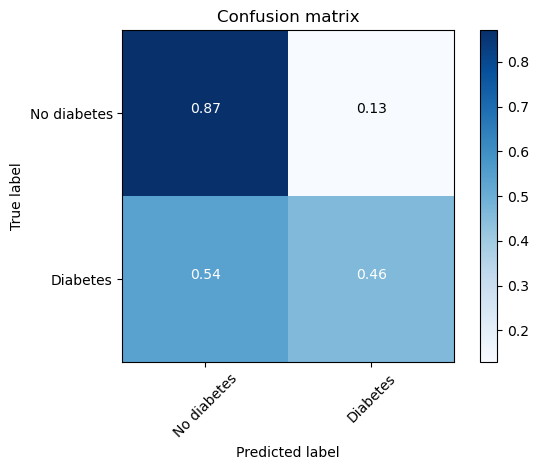

ROC-AUC: 0.799
PR-AUC : 0.359
End time:  18:33:30
Runtime:  0:00:24.866380 



In [37]:
# --- Linear Discriminant Analysis: robust tuning + evaluation ---
import numpy as np
from scipy.stats import uniform, loguniform
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

start_timer()

# Pipeline: preprocess -> LDA  (step named "model" so eval_pipeline works)
lda_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LDA())
])

# --- Search 1: 'svd' solver (shrinkage must be None; tune tol only) ---
svd_dist = {
    "model__solver": ["svd"],
    "model__shrinkage": [None],
    "model__tol": loguniform(1e-6, 1e-2),
}
lda_rs_svd = RandomizedSearchCV(
    estimator=lda_pipe,
    param_distributions=svd_dist,
    n_iter=15,                 # set lower (e.g., 5) for a quick pass
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1,
    error_score=np.nan,        # don't crash on occasional fold issues
)

# --- Search 2a: 'lsqr'/'eigen' with numeric shrinkage in [0,1] ---
le_num_dist = {
    "model__solver": ["lsqr", "eigen"],
    "model__shrinkage": uniform(0.0, 1.0),  # float shrinkage
}
lda_rs_le_num = RandomizedSearchCV(
    estimator=lda_pipe,
    param_distributions=le_num_dist,
    n_iter=15,                 # set lower (e.g., 5) for a quick pass
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1,
    error_score=np.nan,
)

# --- Search 2b: 'lsqr'/'eigen' with shrinkage='auto' (grid is fine) ---
le_auto_grid = {
    "model__solver": ["lsqr", "eigen"],
    "model__shrinkage": ["auto"],
}
lda_gs_le_auto = GridSearchCV(
    estimator=lda_pipe,
    param_grid=le_auto_grid,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
    error_score=np.nan,
)

# ---- Run all searches on your train split ----
lda_rs_svd.fit(X_tr, y_tr)
lda_rs_le_num.fit(X_tr, y_tr)
lda_gs_le_auto.fit(X_tr, y_tr)

# ---- Pick the global best by CV score ----
candidates = [
    ("LDA svd (RS)", lda_rs_svd),
    ("LDA lsqr/eigen numeric shrinkage (RS)", lda_rs_le_num),
    ("LDA lsqr/eigen shrinkage=auto (GS)", lda_gs_le_auto),
]
best_name, best_search = max(candidates, key=lambda t: t[1].best_score_)

print(f"Best LDA variant: {best_name}")
print("Best params:", best_search.best_params_)
print("Best mean CV score:", best_search.best_score_)

# ---- Evaluate on your held-out test split ----
eval_pipeline(best_search.best_estimator_, name=f"{best_name}")

end_timer(); beep_when_done()
